# Telecom Customer Churn Prediction
### Binary Classification using Logistic Regression

**Objective:** Development of a supervised binary classification model
to proactively identify customers at high risk of churn, enabling
targeted retention interventions before revenue loss occurs.

**Dataset:** Telecom dataset — 7,043 customers, 20 features, 26.5% churn rate

**Pipeline Overview:**
Import Libraries → Load the data set → Data Cleaning → Train/Test Split → Feature Engineering → 
Encoding → Scaling → SMOTE → L1 Feature Selection →
Cross Validation → Hyperparameter Tuning → Threshold → Evaluation

In [1]:
#importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection   import (StratifiedKFold, cross_validate ,cross_val_score, RandomizedSearchCV)
from scipy.stats import loguniform
from sklearn.metrics                import (classification_report, confusion_matrix,
                                             roc_auc_score, roc_curve, auc,
                                             f1_score, accuracy_score, recall_score,
                                             precision_score, precision_recall_curve)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
#loading the dataset
data=pd.read_csv("customer_churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 1 — Data Preprocessing

The raw dataset requires several cleaning operations before modelling.
Key issues identified: a non-informative identifier column (`customerID`),
`TotalCharges` stored as object dtype with blank strings, and binary
categorical columns requiring numeric encoding.

**Actions performed:**
- Drop `customerID` — unique identifier with no predictive value
- Coerce `TotalCharges` to float64; impute zero for tenure=0 customers
  and median for any remaining NaN values
- Binary encode Yes/No columns and gender to 1/0

In [3]:
#dropped the customerID
data.drop(columns=['customerID'], inplace=True)

In [4]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [5]:
data.loc[data['tenure'] == 0, 'TotalCharges'] = 0
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())
print('TotalCharges NaN count:', data['TotalCharges'].isnull().sum())
print('Total dataset NaN count:', data.isnull().sum().sum())

TotalCharges NaN count: 0
Total dataset NaN count: 0


####  Map Binary Yes/No Columns to 1/0:

In [6]:
binary_map = {'Yes': 1, 'No': 0}

binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    data[col] = data[col].map(binary_map)

# Gender separately (different category names)
data['gender'] = data['gender'].map({'Female': 1, 'Male': 0})

print(data[['Partner', 'Dependents', 'PhoneService', 'gender', 'Churn']].head())

   Partner  Dependents  PhoneService  gender  Churn
0        1           0             0       1      0
1        0           0             1       0      0
2        0           0             1       0      1
3        0           0             0       0      0
4        0           0             1       1      1


In [7]:
print("Missing values after cleaning:")
print(data.isnull().sum())
print("Number of columns are:",len(data.columns))

Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Number of columns are: 20


## Step 2 — Train/Test Split

The dataset is partitioned into training and test sets **before** any
feature engineering or transformation to prevent data leakage.
All subsequent fitting operations (scaling, SMOTE, feature selection)
are applied to training data only and then transformed onto the test set.

- **Split ratio:** 80% train / 20% test
- **Stratification:** Class distribution preserved across both splits
  (73.6% retained / 26.4% churned in each)
- **Purpose of test set:** Held out entirely until final evaluation —
  never used during model development

In [8]:
x = data.drop('Churn',axis=1)
y = data['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"train data: {x_train.shape} and Churn rate: {round(y_train.mean(),3)}")
print(f"test data: {x_test.shape} and Churn rate:{round(y_test.mean(),3)}")

train data: (5634, 19) and Churn rate: 0.265
test data: (1409, 19) and Churn rate:0.265


## Step 3 — Feature Engineering

Domain-driven features are constructed to capture churn behavioural
patterns not directly present in the raw columns. All statistics
derived from training data only (e.g. `train_median`) are passed
as parameters to avoid leakage into the test set.

**11 engineered features across 4 categories:**

| Category | Feature | Description |
|---|---|---|
| Tenure | `IsFirstYear` | Customer tenure ≤ 12 months |
| Charges | `AvgMonthlyCharge` | TotalCharges / tenure |
| Charges | `HighCostLowTenure` | High spender + new customer |
| Charges | `ChargePerService` | MonthlyCharges / (services + 1) |
| Risk | `FiberOpticUser` | Fiber optic internet flag |
| Risk | `IsMonthToMonth` | Month-to-month contract flag |
| Risk | `PaymentRisk` | Ordinal: auto=1, mailed=2, electronic=3 |
| Risk | `HasFamily` | Partner or Dependents present |
| Risk | `SeniorAlone` | Senior citizen with no family |
| Risk | `SeniorMonthlyNoSupport` | Senior + monthly + no tech support |
| Risk | `MultipleRiskFactors` | Composite risk score 0–4 (strongest feature) |

In [9]:
train_median = x_train['MonthlyCharges'].median()

def clean_service_colms(data):
    data = data.copy()

    service_colms = ['MultipleLines','OnlineSecurity','OnlineBackup',
                    'DeviceProtection','TechSupport',
                    'StreamingTV','StreamingMovies']
    for col in service_colms:
        data[col] = data[col].replace({
            'No phone service'   : 'No',
            'No internet service': 'No'
        })
        data[col] = data[col].map({'Yes':1, 'No':0})
    return data
    
def create_charge_features(data, median_charge):
    data = data.copy()
    data['IsFirstYear']   = (data['tenure'] <= 12).astype(int)

    data['AvgMonthlyCharge'] = data.apply(
        lambda x: x['TotalCharges'] / x['tenure']
        if x['tenure'] > 0 else x['MonthlyCharges'], axis=1
    )
    data['HighCostLowTenure'] = (
        (data['MonthlyCharges'] > median_charge) &
        (data['tenure'] < 12)
    ).astype(int)
    return data
    
def create_service_features(data):
    data = data.copy()
    all_svcs = ['PhoneService','MultipleLines','OnlineSecurity',
                'OnlineBackup','DeviceProtection','TechSupport',
                'StreamingTV','StreamingMovies']
    total_svcs             = data[all_svcs].sum(axis=1)
    data['ChargePerService'] = data['MonthlyCharges'] / (total_svcs + 1)
    return data

def create_risk_features(data):
    data = data.copy()
    data['FiberOpticUser'] = (data['InternetService'] == 'Fiber optic').astype(int)
    data['IsMonthToMonth'] = (data['Contract'] == 'Month-to-month').astype(int)

    data['PaymentRisk'] = data['PaymentMethod'].map({
        'Electronic check'          : 3,
        'Mailed check'              : 2,
        'Bank transfer (automatic)' : 1,
        'Credit card (automatic)'   : 1
    })
    data['HasFamily'] = (
        (data['Partner'] == 1) | (data['Dependents'] == 1)
    ).astype(int)

    data['SeniorAlone'] = (
        (data['SeniorCitizen'] == 1) &
        (data['Partner']       == 0) &
        (data['Dependents']    == 0)
    ).astype(int)

    data['SeniorMonthlyNoSupport'] = (
        (data['SeniorCitizen'] == 1) &
        (data['IsMonthToMonth'] == 1) &
        (data['TechSupport']    == 0)
    ).astype(int)

    data['MultipleRiskFactors'] = (
        data['IsMonthToMonth'] +
        data['FiberOpticUser'] +
        (data['PaymentRisk'] == 3).astype(int) +
        (data['tenure'] <= 12).astype(int)
    )
    return data
    
def run_all_features(data, median_charge):
    data = clean_service_colms(data)
    data = create_charge_features(data, median_charge)
    data = create_service_features(data)
    data = create_risk_features(data)
    return data


x_train = run_all_features(x_train, train_median)
x_test  = run_all_features(x_test,  train_median)

print('Features after engineering — Train data:', x_train.shape[1])

Features after engineering — Train data: 30


## Step 4 — Categorical Encoding

Remaining categorical columns are converted to numeric representations
suitable for Logistic Regression.

- **One-hot encoding** (`pd.get_dummies`, `drop_first=True`): Applied to
  unordered categorical columns — avoids false ordinal relationships
- **Column alignment** (`.align(join='left')`): Ensures test set has
  identical feature columns as train set; missing categories filled with 0

`drop_first=True` removes one redundant dummy column per feature to
prevent multicollinearity (dummy variable trap).

In [10]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test  = pd.get_dummies(x_test,  drop_first=True)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

print('Encoded — Train:', x_train.shape, '| Test:', x_test.shape)

Encoded — Train: (5634, 34) | Test: (1409, 34)


## Step 5 — Feature Scaling

Logistic Regression is sensitive to the scale of input features.
Without scaling, features with large numeric ranges (e.g. `TotalCharges`)
dominate the model over features with small ranges (e.g. `tenure`).

- **Method:** StandardScaler — Z-score normalisation (mean=0, std=1)
- **Fit on train only:** Scaler learns mean and std from training data
- **Transform both:** Same statistics applied to test set — no leakage

In [11]:
scaler = StandardScaler()

scaler.fit(x_train)  

X_train_scaled = scaler.transform(x_train) 
X_test_scaled  = scaler.transform(x_test)    

print('Scaling complete. Shape:', X_train_scaled.shape)

Scaling complete. Shape: (5634, 34)


## Step 6 — Class Imbalance Handling (SMOTE)

The training set has a 2.78:1 class imbalance (73.6% retained vs 26.4%
churned). Without correction, the model would be biased toward predicting
the majority class, achieving high accuracy while failing to identify churners.

**SMOTE (Synthetic Minority Oversampling Technique):**
Creates synthetic churn samples by interpolating between real churners
and their k-nearest neighbours in feature space.

- **Applied after scaling** — synthetic points created in scaled space
  ensuring fair distance calculations
- **Applied to training data only** — test set preserves real-world
  class distribution for unbiased evaluation
- **Result:** Balanced training set of 4139 retained + 4139 churned

In [12]:
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', dict(zip(*np.unique(y_train,     return_counts=True))))
print('After  SMOTE:', dict(zip(*np.unique(y_train_res, return_counts=True))))
print(f'\nTraining rows: {len(y_train)} → {len(y_train_res)} (+{len(y_train_res)-len(y_train)} synthetic churn samples)')

Before SMOTE: {np.int64(0): np.int64(4139), np.int64(1): np.int64(1495)}
After  SMOTE: {np.int64(0): np.int64(4139), np.int64(1): np.int64(4139)}

Training rows: 5634 → 8278 (+2644 synthetic churn samples)


## Step 7 — L1 Regularisation Feature Selection

With 34 features post-encoding, not all contribute meaningful signal.
Redundant or weak features introduce noise and increase overfitting risk.

**L1 (Lasso) Regularisation** applies a penalty that shrinks weak
feature coefficients to **exactly zero**, effectively removing them.
`SelectFromModel` retains only features with non-zero coefficients.

- **Solver:** `liblinear` — only solver supporting L1 penalty
- **C = 0.1** — moderate regularisation; stronger penalty removes more features
- **Input:** SMOTE-balanced training data (balanced data ensures fair selection)
- **Same mask applied to test set** — consistent feature space maintained

In [13]:
l1_selector = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.1,
    max_iter=1000, random_state=42
)
l1_selector.fit(X_train_res, y_train_res)

l1_mask           = l1_selector.coef_[0] != 0
selected_features = x_train.columns[l1_mask].tolist()

X_train_sel = X_train_res[:,  l1_mask]
X_test_sel  = X_test_scaled[:, l1_mask]

print(f'Features before L1 : {X_train_res.shape[1]}')
print(f'Features after  L1 : {X_train_sel.shape[1]}')
print(f'\nSelected features  : {selected_features}')

Features before L1 : 34
Features after  L1 : 25

Selected features  : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'TotalCharges', 'IsFirstYear', 'HighCostLowTenure', 'ChargePerService', 'FiberOpticUser', 'IsMonthToMonth', 'HasFamily', 'SeniorMonthlyNoSupport', 'MultipleRiskFactors', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Two year']


## Step 8 — Cross Validation (Baseline Evaluation)

Before hyperparameter tuning, a baseline performance estimate is
established using Stratified K-Fold cross validation. This provides
a reliable, variance-reduced performance estimate compared to a
single train/validation split.

- **Strategy:** StratifiedKFold (k=5) — preserves class ratio across all folds
- **Primary metric:** Recall — minimising false negatives is the business priority
- **Additional metrics:** F1 Score (precision-recall balance), ROC-AUC (ranking quality)

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model = LogisticRegression(max_iter=1000, random_state=42)

cv_recall = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='recall')
cv_f1     = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='f1')
cv_auc    = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='roc_auc')

print(f'CV Recall  : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}')
print(f'CV F1      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'CV ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

CV Recall  : 0.8128 ± 0.0103
CV F1      : 0.7826 ± 0.0055
CV ROC-AUC : 0.8516 ± 0.0024


## Step 9 — Hyperparameter Tuning (RandomizedSearchCV)

The baseline model uses default hyperparameters. Tuning identifies the
optimal configuration that maximises recall on the SMOTE-balanced training data.

**RandomizedSearchCV** samples 20 random combinations from the search space,
each evaluated via 5-fold stratified cross validation.
More efficient than exhaustive GridSearch for continuous parameter ranges.

**Search space:**
- `C` : loguniform(0.01, 10) — log-uniform sampling captures equal density
  across orders of magnitude; range chosen to cover the performance sweet spot
- `penalty` : L1 or L2 regularisation
- `solver` : liblinear (required for L1 support)
- `max_iter` : 500 or 1000

**Scoring metric:** Recall — aligned with business cost asymmetry

In [15]:
param_dist = {
    'C'        : loguniform(0.01, 10),
    'penalty'  : ['l1', 'l2'],
    'solver'   : ['liblinear'],
    'max_iter' : [500, 1000]
}

random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions = param_dist,
    n_iter     = 20,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'recall',
    n_jobs     = -1,
    random_state = 42
)

random_search.fit(X_train_sel, y_train_res)
best_model = random_search.best_estimator_

print('Best Parameters :', random_search.best_params_)
print('Best CV Recall  :', round(random_search.best_score_, 4))


best_model.fit(X_train_sel, y_train_res)
print('\nModel refitted on full SMOTE training set.')

Best Parameters : {'C': np.float64(0.014936568554617643), 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall  : 0.8171

Model refitted on full SMOTE training set.


## Step 10 — Decision Threshold

The model outputs a **churn probability** (0–1) for each customer,
not a direct class label. A threshold converts this probability
into a binary prediction.

- **Default threshold = 0.50** — predicts churn only when probability exceeds 50%.

**Note:** For production deployment, threshold optimisation is recommended.
Lowering the threshold increases recall (more churners caught) at the cost
of precision (more false alarms).A threshold of 0.30–0.35 typically maximises net
business value for churn use cases but can increase the false alarms.

In [16]:
y_prob = best_model.predict_proba(X_test_sel)[:, 1]

THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f'Threshold applied : {THRESHOLD}')
print(f'Predicted churners: {y_pred.sum()} / {len(y_pred)}')

Threshold applied : 0.5
Predicted churners: 600 / 1409


## Step 11 — Final Model Evaluation

The trained model is evaluated on the **held-out test set** — data
the model has never seen during any stage of training, tuning, or selection.
This provides an unbiased estimate of real-world predictive performance.

**Metrics reported:**
- **Accuracy** — overall correct predictions (less meaningful under imbalance)
- **Recall** — proportion of actual churners correctly identified (primary metric)
- **Precision** — proportion of churn predictions that were correct
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — model's ability to rank churners above non-churners

**Overfitting check:** Train vs test accuracy compared — a small gap
confirms the model generalises well to unseen data.

In [21]:
y_pred = best_model.predict(X_test_sel)
y_prob = best_model.predict_proba(X_test_sel)[:, 1]

y_train_pred = best_model.predict(X_train_sel)   
acc          = accuracy_score(y_test, y_pred)

print('=== Final Model Performance on Test Set ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'f1 score  : {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
print(f'                 Predicted Stayed  Predicted Churned')
print(f'Actual Stayed         {cm[0][0]}              {cm[0][1]}')
print(f'Actual Churned        {cm[1][0]}              {cm[1][1]}')
print()
print(f'True Negatives  (correctly said stayed)  : {cm[0][0]}')
print(f'False Positives (wrongly said churned)   : {cm[0][1]}')
print(f'False Negatives (missed real churners)   : {cm[1][0]}')
print(f'True Positives  (correctly caught churn) : {cm[1][1]}')
print()
print(f'\nTrain Accuracy: {accuracy_score(y_train_res, y_train_pred):.4f}')
print(f'Test  Accuracy: {acc:.4f}')
print()
print("(Small gap = no overfitting)")

=== Final Model Performance on Test Set ===
Accuracy  : 0.7402
ROC-AUC   : 0.8390
Recall    : 0.8128
Precision : 0.5067
f1 score  : 0.6242

              precision    recall  f1-score   support

      Stayed       0.91      0.71      0.80      1035
     Churned       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409

Confusion Matrix:
                 Predicted Stayed  Predicted Churned
Actual Stayed         739              296
Actual Churned        70              304

True Negatives  (correctly said stayed)  : 739
False Positives (wrongly said churned)   : 296
False Negatives (missed real churners)   : 70
True Positives  (correctly caught churn) : 304


Train Accuracy: 0.7727
Test  Accuracy: 0.7402

(Small gap = no overfitting)


## Step 12  — Visualization

### Visualization 1 — Confusion matrix

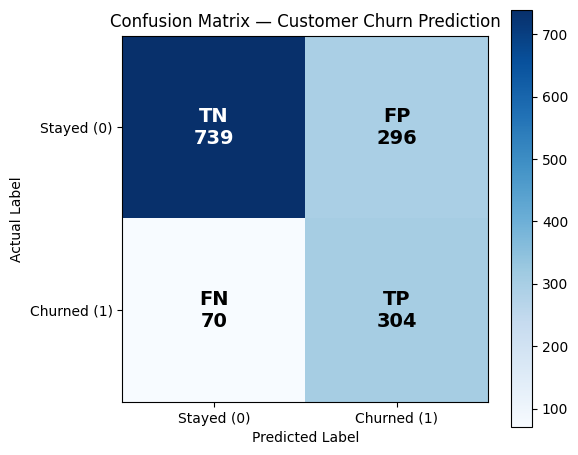

In [25]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

classes = ['Stayed (0)', 'Churned (1)']
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(classes); ax.set_yticklabels(classes)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix — Customer Churn Prediction')

thresh = cm.max() / 2
labels = [['TN','FP'],['FN','TP']]
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > thresh else 'black'
        ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]}',
                ha='center', va='center', fontsize=14,
                fontweight='bold', color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Visualization 2 — ROC Curve

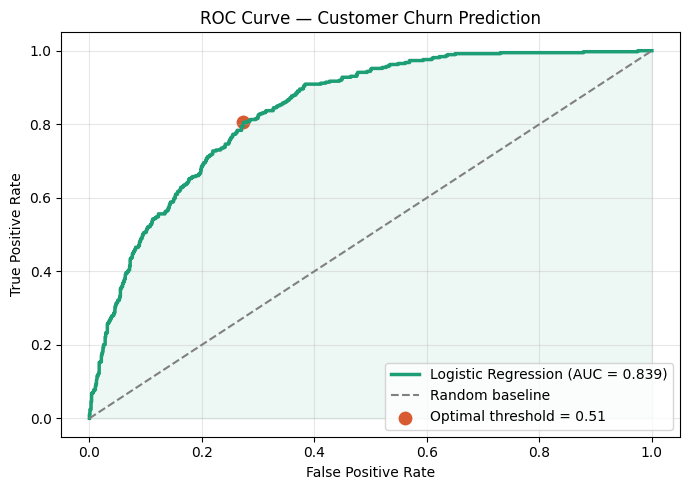

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#1D9E75', lw=2.5,
        label=f'Logistic Regression (AUC = {auc_score:.3f})')
ax.plot([0,1],[0,1], color='gray', lw=1.5,
        linestyle='--', label='Random baseline')

# Optimal threshold point
opt_idx = np.argmin(np.sqrt(fpr**2 + (tpr-1)**2))
ax.scatter(fpr[opt_idx], tpr[opt_idx], color='#D85A30', s=80,
           label=f'Optimal threshold = {thresholds[opt_idx]:.2f}')

ax.fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Customer Churn Prediction')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 3 — Class Imbalance Before/After SMOTE

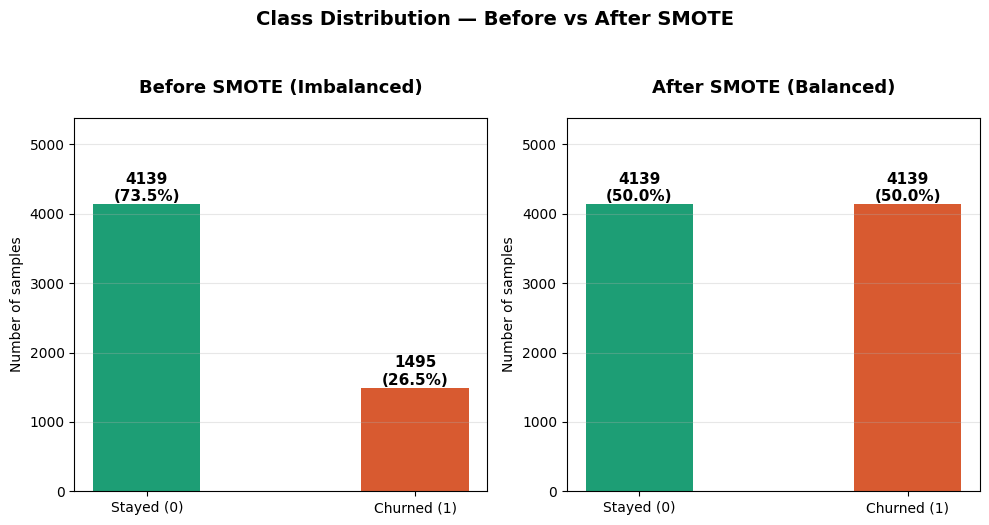

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, counts, title in zip(axes,
                              [before, after],
                              ['Before SMOTE (Imbalanced)',
                               'After SMOTE (Balanced)']):
    bars = ax.bar(x, counts, width=0.4, color=colors) 
    ax.set_title(title, fontsize=13, fontweight='bold', pad=18)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('Number of samples')
    ax.set_ylim(0, max(counts) * 1.3)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, counts):
        pct = val / sum(counts) * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 40,
                f'{val}\n({pct:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')

fig.suptitle('Class Distribution — Before vs After SMOTE',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()